In [32]:
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv("../data/movies.csv")

In [34]:
df.head()


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


## Inspect dataframe structure

In [35]:
df.shape

(7668, 15)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7591 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   released  7666 non-null   object 
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   object 
 8   writer    7665 non-null   object 
 9   star      7667 non-null   object 
 10  country   7665 non-null   object 
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   object 
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 898.7+ KB


In [37]:
df.isna().sum()

name           0
rating        77
genre          0
year           0
released       2
score          3
votes          3
director       0
writer         3
star           1
country        3
budget      2171
gross        189
company       17
runtime        4
dtype: int64

## Prepare clean dataset for analysys

In [43]:
colums = ["name", "genre", "year", "score", "votes", "runtime"]
df_movies = df[colums]

In [39]:
df_movies.isna().sum()

name       0
genre      0
year       0
score      3
votes      3
runtime    4
dtype: int64

In [40]:
df_movies = df_movies.dropna()
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7661 entries, 0 to 7667
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   name     7661 non-null   object 
 1   genre    7661 non-null   object 
 2   year     7661 non-null   int64  
 3   score    7661 non-null   float64
 4   votes    7661 non-null   float64
 5   runtime  7661 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 419.0+ KB


### Score Distribution — Summary Statistics

The dataset contains 7,668 movies, with 7,661 non-null values for the score column.
The number of missing values is very small and does not significantly affect the analysis.

The average movie rating is 6.39, while the median rating is 6.5.
Since the mean is slightly lower than the median, this suggests a slight skew toward lower-rated movies.

The standard deviation is 0.97, which indicates a moderate spread of ratings.
Most movies have scores approximately between 5.4 and 7.4.

Half of the movies (the interquartile range) fall within a relatively narrow range from 5.8 to 7.1, meaning that the majority of films receive similar ratings.

The minimum score in the dataset is 1.9, and the maximum score is 9.3.
These extreme values are rare and represent outliers rather than typical movies.

Overall, most movies in the dataset are rated between 6 and 7, with very low and very high ratings occurring infrequently.

In [41]:
df_movies["score"].describe().round(2)

count    7661.00
mean        6.39
std         0.97
min         1.90
25%         5.80
50%         6.50
75%         7.10
max         9.30
Name: score, dtype: float64

### Score Distribution — Histogram

The histogram shows that movie ratings are concentrated between approximately 6 and 7.  
This confirms the summary statistics, where the mean score is 6.39 and the median is 6.5.

The distribution is slightly skewed toward lower ratings, indicating that a small number of low-rated movies pull the average down.  
Very low and very high ratings occur infrequently and represent a small portion of the dataset.


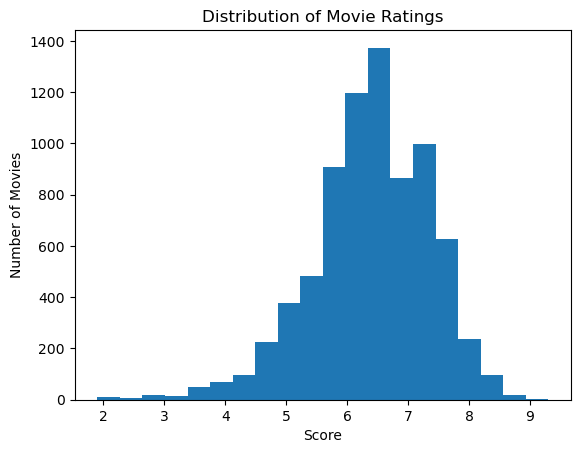

In [42]:
df_movies["score"].plot(kind="hist", bins=20)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Score")
plt.ylabel("Number of Movies")

plt.show()

## Average Movie Ratings by Genre

In this section, we analyze how movie ratings vary across different genres.  
The goal is to compare the average score for each genre and identify which genres tend to receive higher or lower ratings.


In [48]:
avg_score_by_genre = df_movies.groupby("genre")["score"].mean().round(2).sort_values(ascending=False)
avg_score_by_genre

genre
History      8.30
Musical      8.05
Music        7.20
Biography    7.03
Animation    6.77
Drama        6.69
Crime        6.67
Mystery      6.67
Romance      6.41
Family       6.36
Adventure    6.29
Sci-Fi       6.21
Action       6.20
Comedy       6.19
Fantasy      6.01
Thriller     5.91
Sport        5.90
Horror       5.75
Western      5.67
Name: score, dtype: float64

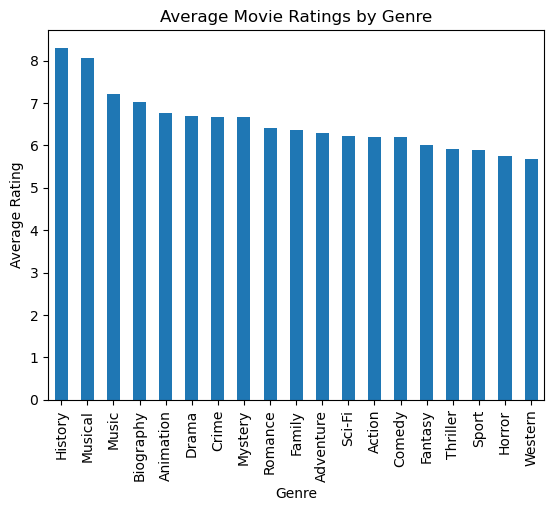

In [ ]:
avg_score_by_genre.plot(
    kind="bar",
    title="Average Movie Ratings by Genre",
    ylabel="Average Rating",
    xlabel="Genre"
    )

plt.show()

The table and graph above shows the average score for each genre.
History and Musical genres appear to have the highest average ratings, while Horror and Western are among the lowest.

However, these results should be interpreted with caution. Genres with fewer movies may have inflated average scores. To assess the reliability of these ratings, the number of movies per genre must be analyzed alongside the average score.


## Genre Rating Distribution: Mean, Median and Count

In this section, we analyze the reliability of average ratings by comparing
mean and median scores and considering the number of movies per genre.

In [54]:
movie_count_by_genre = df_movies.groupby("genre")["name"].count().sort_values(ascending=False)
movie_count_by_genre

genre
Comedy       2245
Action       1705
Drama        1518
Crime         551
Biography     443
Adventure     427
Animation     338
Horror        322
Fantasy        44
Mystery        20
Thriller       16
Family         11
Romance        10
Sci-Fi         10
Western         3
Musical         2
Sport           1
Music           1
History         1
Name: name, dtype: int64

In [55]:
median_score_by_genre = df_movies.groupby("genre")["score"].median().round(2).sort_values(ascending=False)
median_score_by_genre

genre
History      8.30
Musical      8.05
Music        7.20
Biography    7.10
Animation    6.80
Crime        6.70
Drama        6.70
Mystery      6.65
Romance      6.55
Adventure    6.40
Comedy       6.30
Family       6.30
Action       6.20
Thriller     6.15
Sci-Fi       6.10
Fantasy      6.05
Sport        5.90
Horror       5.80
Western      5.50
Name: score, dtype: float64

In [56]:
df_genre_rating_summary = pd.concat({
        "mean_score": avg_score_by_genre,
        "median_score": median_score_by_genre,
        "movie_count": movie_count_by_genre
        },
        axis=1)
df_genre_rating_summary

,mean_score,median_score,movie_count
genre,,,
History,8.30,8.30,1
Musical,8.05,8.05,2
Music,7.20,7.20,1
Biography,7.03,7.10,443
Animation,6.77,6.80,338
Drama,6.69,6.70,1518
Crime,6.67,6.70,551
Mystery,6.67,6.65,20
Romance,6.41,6.55,10


Genres such as History, Music, Musical, and Sport show very high average ratings. However, these genres contain only one or two movies, making their statistics unreliable.

Genres with a large number of movies (e.g. Comedy, Action, Drama) provide more stable and representative rating estimates. In these genres, the mean and median ratings are very close, indicating a relatively symmetric distribution of scores.

In some genres, such as Thriller and Romance, the median rating is higher than the mean. This suggests the presence of low-rated outliers that pull the average score downward.

### Summary

The analysis shows that average movie ratings by genre should not be interpreted in isolation. The number of movies and the distribution of ratings play a crucial role in assessing the reliability of genre-level statistics.